# Criminalidade em Grandes Cidades Brasileiras

## 1. Introdução
Analisar ocorrências criminais em cidades brasileiras entre 2015 e 2024,
comparando locais, tipos de crime e períodos, além de investigar a
relação entre renda média e violência.

## 2. Explicação da base
A base simulada contém 4.440 registros e 15 colunas, abrangendo 37 cidades.
Inclui localização, período, tipo de crime, ocorrências, vítimas, prisões,
renda média, índice de violência e nível de risco.

Os dados são acadêmicos e não representam estatísticas oficiais.
As quantidades de crimes serão calculadas pela soma da coluna ocorrencias.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("simulacao_criminalidade_brasil.csv")

print("Quantidade de registros:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

display(df.head())

print("\nTipos das colunas:")
df.info()

print("\nValores ausentes por coluna:")
print(df.isna().sum())

print("\nLinhas completamente duplicadas:", df.duplicated().sum())

Quantidade de registros: 4440
Quantidade de colunas: 15


,ano,mes,data,regiao,uf,cidade,bairro,tipo_crime,periodo_dia,ocorrencias,vitimas,prisoes,renda_media,indice_violencia,nivel_risco
0,2015,1,2015-01-01,Norte,AM,Manaus,Centro,Estelionato,Madrugada,42,6,5,2391.23,72.87,Médio
1,2015,1,2015-01-01,Norte,PA,Belém,Zona Norte,Furto,Noite,25,4,3,3126.24,85.27,Crítico
2,2015,1,2015-01-01,Norte,PA,Santarém,Periferia,Furto,Manhã,22,1,3,3315.82,73.02,Alto
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Zona Sul,Violência doméstica,Tarde,27,5,4,4076.73,106.82,Alto
4,2015,1,2015-01-01,Norte,TO,Palmas,Zona Sul,Estelionato,Madrugada,27,6,4,3494.94,60.85,Crítico



Tipos das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ano               4440 non-null   int64  
 1   mes               4440 non-null   int64  
 2   data              4440 non-null   object 
 3   regiao            4440 non-null   object 
 4   uf                4440 non-null   object 
 5   cidade            4440 non-null   object 
 6   bairro            4440 non-null   object 
 7   tipo_crime        4440 non-null   object 
 8   periodo_dia       4440 non-null   object 
 9   ocorrencias       4440 non-null   int64  
 10  vitimas           4440 non-null   int64  
 11  prisoes           4440 non-null   int64  
 12  renda_media       4440 non-null   float64
 13  indice_violencia  4440 non-null   float64
 14  nivel_risco       4440 non-null   object 
dtypes: float64(2), int64(5), object(8)
memory usage: 520.4+ KB

Valores a

## 3. Limpeza e preparação
Nesta etapa, serão padronizados os textos, convertidas as datas e
verificada a consistência dos valores numéricos e dos períodos.
Linhas totalmente duplicadas serão removidas, caso existam.

In [3]:
df_original = df.copy()

df.columns = df.columns.str.strip()

colunas_texto = [
    "regiao", "uf", "cidade", "bairro",
    "tipo_crime", "periodo_dia", "nivel_risco"
]

for coluna in colunas_texto:
    df[coluna] = df[coluna].astype("string").str.strip()

df["data"] = pd.to_datetime(
    df["data"], format="%Y-%m-%d", errors="coerce"
)

colunas_numericas = [
    "ano", "mes", "ocorrencias", "vitimas",
    "prisoes", "renda_media", "indice_violencia"
]

for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

duplicadas = df.duplicated().sum()
df = df.drop_duplicates().copy()

print("Linhas duplicadas removidas:", duplicadas)
print("Datas inválidas:", df["data"].isna().sum())
print("Valores ausentes após conversão:", df.isna().sum().sum())

print("\nValores negativos:")
print(
    (df[[
        "ocorrencias", "vitimas", "prisoes",
        "renda_media", "indice_violencia"
    ]] < 0).sum()
)

periodos_inconsistentes = (
    df["data"].notna()
    & (
        (df["ano"] != df["data"].dt.year)
        | (df["mes"] != df["data"].dt.month)
    )
)

print("\nMeses fora de 1 a 12:", (~df["mes"].between(1, 12)).sum())
print("Ano ou mês diferente da data:", periodos_inconsistentes.sum())

display(df.head())

Linhas duplicadas removidas: 0
Datas inválidas: 0
Valores ausentes após conversão: 0

Valores negativos:
ocorrencias         0
vitimas             0
prisoes             0
renda_media         0
indice_violencia    0
dtype: int64

Meses fora de 1 a 12: 0
Ano ou mês diferente da data: 0


,ano,mes,data,regiao,uf,cidade,bairro,tipo_crime,periodo_dia,ocorrencias,vitimas,prisoes,renda_media,indice_violencia,nivel_risco
0,2015,1,2015-01-01,Norte,AM,Manaus,Centro,Estelionato,Madrugada,42,6,5,2391.23,72.87,Médio
1,2015,1,2015-01-01,Norte,PA,Belém,Zona Norte,Furto,Noite,25,4,3,3126.24,85.27,Crítico
2,2015,1,2015-01-01,Norte,PA,Santarém,Periferia,Furto,Manhã,22,1,3,3315.82,73.02,Alto
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Zona Sul,Violência doméstica,Tarde,27,5,4,4076.73,106.82,Alto
4,2015,1,2015-01-01,Norte,TO,Palmas,Zona Sul,Estelionato,Madrugada,27,6,4,3494.94,60.85,Crítico


## 4. Engenharia de atributos
Serão criadas colunas de ano e mês, nome do mês e trimestre para
facilitar os agrupamentos e as análises temporais.

In [4]:
nomes_meses = {
    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}

df["ano_mes"] = df["data"].dt.to_period("M").astype(str)
df["nome_mes"] = df["mes"].map(nomes_meses)
df["trimestre"] = df["data"].dt.quarter

df = df.sort_values(["data", "regiao", "uf", "cidade"]).reset_index(drop=True)

display(df[[
    "data", "ano", "mes", "ano_mes",
    "nome_mes", "trimestre", "cidade", "ocorrencias"
]].head())

,data,ano,mes,ano_mes,nome_mes,trimestre,cidade,ocorrencias
0,2015-01-01,2015,1,2015-01,Janeiro,1,Brasília,26
1,2015-01-01,2015,1,2015-01,Janeiro,1,Aparecida de Goiânia,36
2,2015-01-01,2015,1,2015-01,Janeiro,1,Goiânia,35
3,2015-01-01,2015,1,2015-01,Janeiro,1,Campo Grande,32
4,2015-01-01,2015,1,2015-01,Janeiro,1,Cuiabá,43


## 5. Indicadores principais — KPIs
Os indicadores resumem as ocorrências, vítimas, prisões e o índice
de violência da base. Os rankings utilizam quantidades absolutas,
sem ajuste pela população.

A região com maior índice médio de violência será considerada a
mais crítica segundo esse indicador.

In [5]:
ranking_cidades = (
    df.groupby(["cidade", "uf"])["ocorrencias"]
    .sum()
    .sort_values(ascending=False)
)

ranking_crimes = (
    df.groupby("tipo_crime")["ocorrencias"]
    .sum()
    .sort_values(ascending=False)
)

ranking_regioes_indice = (
    df.groupby("regiao")["indice_violencia"]
    .mean()
    .sort_values(ascending=False)
)

cidade, uf = ranking_cidades.index[0]

kpis = pd.DataFrame({
    "Indicador": [
        "Total de ocorrências",
        "Total de vítimas",
        "Total de prisões",
        "Índice médio de violência",
        "Cidade com mais ocorrências",
        "Crime com mais ocorrências",
        "Região com maior índice médio de violência"
    ],
    "Resultado": [
        f"{df['ocorrencias'].sum():,.0f}".replace(",", "."),
        f"{df['vitimas'].sum():,.0f}".replace(",", "."),
        f"{df['prisoes'].sum():,.0f}".replace(",", "."),
        f"{df['indice_violencia'].mean():.2f}".replace(".", ","),
        f"{cidade} — {uf}",
        ranking_crimes.index[0],
        ranking_regioes_indice.index[0]
    ]
})

display(kpis)

,Indicador,Resultado
0,Total de ocorrências,132.845
1,Total de vítimas,22.220
2,Total de prisões,13.219
3,Índice médio de violência,"64,67"
4,Cidade com mais ocorrências,Florianópolis — SC
5,Crime com mais ocorrências,Roubo
6,Região com maior índice médio de violência,Norte


## 6. Análise exploratória
Nesta etapa, serão examinadas as estatísticas das variáveis numéricas
e a evolução anual das ocorrências na base simulada.

In [6]:
display(
    df[[
        "ocorrencias", "vitimas", "prisoes",
        "renda_media", "indice_violencia"
    ]].describe().round(2)
)

ocorrencias_ano = (
    df.groupby("ano", as_index=False)["ocorrencias"]
    .sum()
    .sort_values("ano")
)

ocorrencias_ano["variacao_percentual"] = (
    ocorrencias_ano["ocorrencias"].pct_change() * 100
)

display(ocorrencias_ano.round(2))

,ocorrencias,vitimas,prisoes,renda_media,indice_violencia
count,4440.00,4440.00,4440.00,4440.00,4440.00
mean,29.92,5.00,2.98,2781.47,64.67
std,5.43,2.25,1.72,644.16,31.54
min,14.00,0.00,0.00,689.71,10.02
25%,26.00,3.00,2.00,2357.45,37.26
50%,30.00,5.00,3.00,2795.62,64.80
75%,33.00,6.00,4.00,3209.48,91.26
max,53.00,16.00,12.00,5138.46,119.95


,ano,ocorrencias,variacao_percentual
0,2015,13269,NaN
1,2016,13223,-0.35
2,2017,13227,0.03
3,2018,13351,0.94
4,2019,13426,0.56
5,2020,13233,-1.44
6,2021,13260,0.20
7,2022,13202,-0.44
8,2023,13400,1.50
9,2024,13254,-1.09


## 7. Visualizações
### 7.1. Evolução anual das ocorrências
O gráfico apresenta o total de ocorrências por ano entre 2015 e 2024.

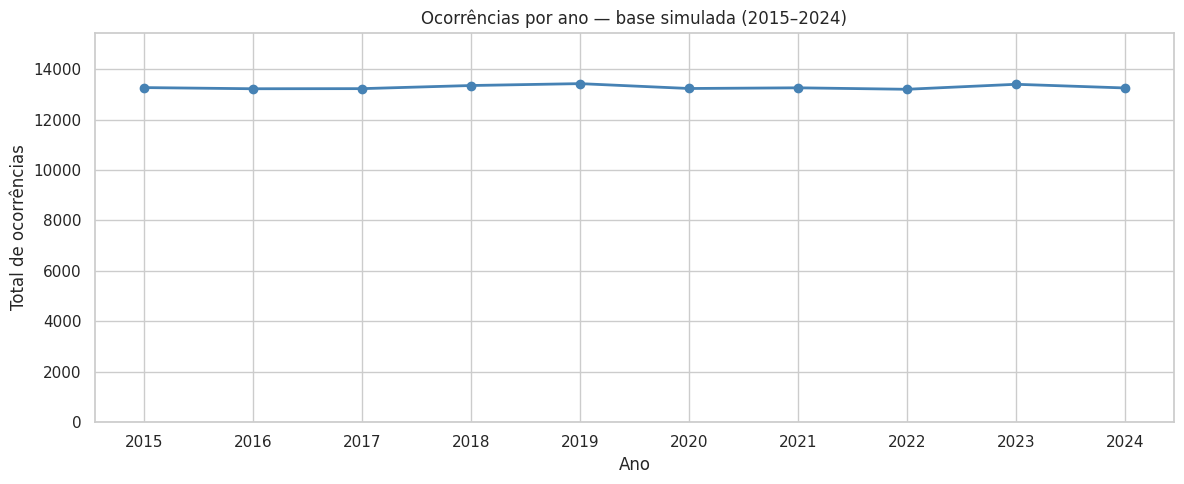

Variação entre 2015 e 2024: -0.11%
Ano com maior total de ocorrências: 2019


In [7]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    ocorrencias_ano["ano"],
    ocorrencias_ano["ocorrencias"],
    marker="o",
    color="steelblue",
    linewidth=2
)

ax.set_title("Ocorrências por ano — base simulada (2015–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("Total de ocorrências")
ax.set_xticks(ocorrencias_ano["ano"])
ax.set_ylim(0, ocorrencias_ano["ocorrencias"].max() * 1.15)

plt.tight_layout()
plt.show()

total_inicial = ocorrencias_ano.iloc[0]["ocorrencias"]
total_final = ocorrencias_ano.iloc[-1]["ocorrencias"]
variacao = (total_final / total_inicial - 1) * 100

ano_maior = int(
    ocorrencias_ano.loc[
        ocorrencias_ano["ocorrencias"].idxmax(), "ano"
    ]
)

print(f"Variação entre 2015 e 2024: {variacao:.2f}%")
print(f"Ano com maior total de ocorrências: {ano_maior}")

### 7.2. Cidades com maior número de ocorrências
O gráfico compara as dez cidades com maior total de ocorrências entre
2015 e 2024. Os valores são absolutos e não consideram o tamanho da
população de cada cidade.

,cidade,uf,ocorrencias
10,Florianópolis,SC,3707
12,Goiânia,GO,3672
3,Brasília,DF,3670
1,Belo Horizonte,MG,3665
23,Petrópolis,RJ,3664
14,Joinville,SC,3659
19,Manaus,AM,3652
4,Campinas,SP,3645
0,Aparecida de Goiânia,GO,3639
32,São Luís,MA,3635


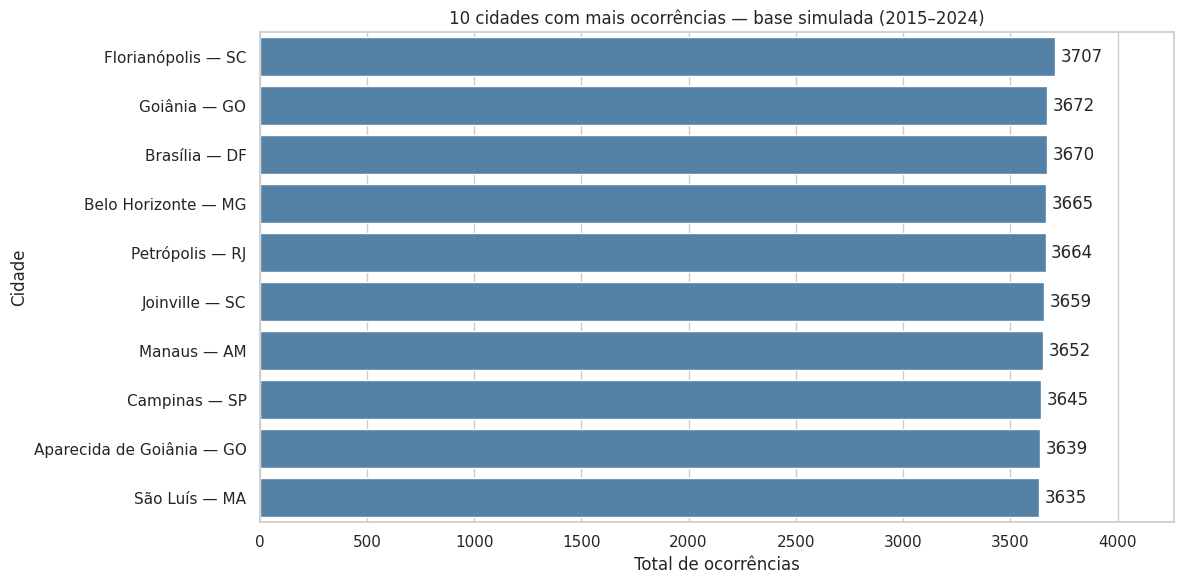

Cidade com mais ocorrências: Florianópolis — SC
Total de ocorrências: 3707
Participação no total da base: 2.79%


In [8]:
top_cidades = (
    df.groupby(["cidade", "uf"], as_index=False)["ocorrencias"]
    .sum()
    .sort_values("ocorrencias", ascending=False)
    .head(10)
)

top_cidades["cidade_uf"] = (
    top_cidades["cidade"] + " — " + top_cidades["uf"]
)

display(top_cidades[["cidade", "uf", "ocorrencias"]])

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_cidades,
    x="ocorrencias",
    y="cidade_uf",
    color="steelblue",
    ax=ax
)

ax.set_title("10 cidades com mais ocorrências — base simulada (2015–2024)")
ax.set_xlabel("Total de ocorrências")
ax.set_ylabel("Cidade")

ax.bar_label(ax.containers[0], fmt="%.0f", padding=4)
ax.set_xlim(0, top_cidades["ocorrencias"].max() * 1.15)

plt.tight_layout()
plt.show()

primeira = top_cidades.iloc[0]
participacao = primeira["ocorrencias"] / df["ocorrencias"].sum() * 100

print(
    f"Cidade com mais ocorrências: "
    f"{primeira['cidade']} — {primeira['uf']}"
)
print(f"Total de ocorrências: {primeira['ocorrencias']:.0f}")
print(f"Participação no total da base: {participacao:.2f}%")

O ranking identifica as cidades com maior quantidade de ocorrências
na base simulada. Uma posição mais alta não significa necessariamente
maior risco individual, pois não foram calculadas taxas por habitante.

### 7.3. Ocorrências por tipo de crime
O gráfico compara o total de ocorrências de cada tipo de crime
entre 2015 e 2024, utilizando a soma da coluna ocorrencias.

,tipo_crime,ocorrencias,participacao_percentual
3,Roubo,23440,17.64
4,Tráfico,23337,17.57
0,Estelionato,21887,16.48
5,Violência doméstica,21505,16.19
2,Homicídio,21497,16.18
1,Furto,21179,15.94


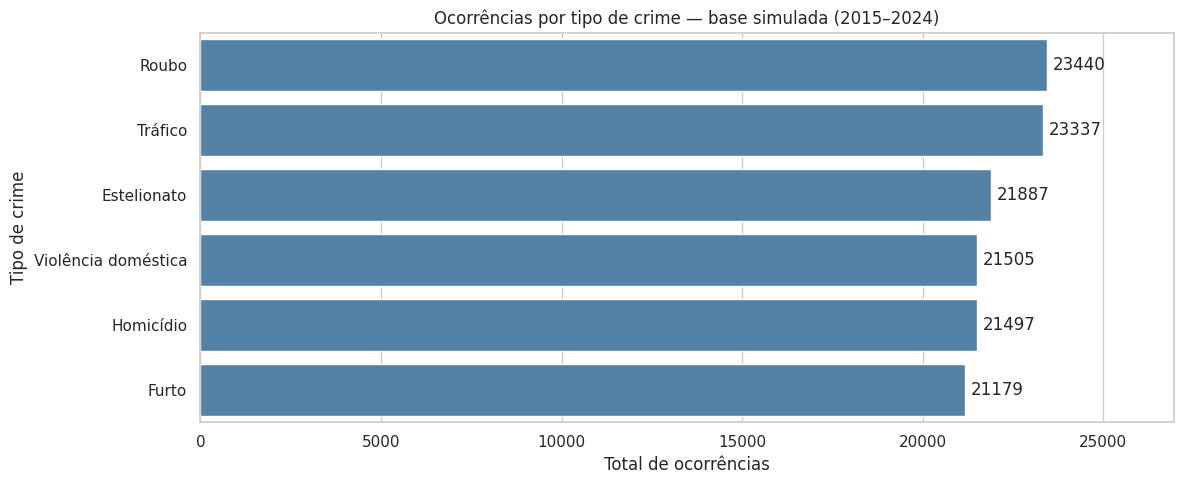

Crime com mais ocorrências: Roubo
Total de ocorrências: 23440
Participação no total: 17.64%


In [9]:
crimes = (
    df.groupby("tipo_crime", as_index=False)["ocorrencias"]
    .sum()
    .sort_values("ocorrencias", ascending=False)
)

crimes["participacao_percentual"] = (
    crimes["ocorrencias"] / crimes["ocorrencias"].sum() * 100
)

display(crimes.round(2))

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=crimes,
    x="ocorrencias",
    y="tipo_crime",
    color="steelblue",
    ax=ax
)

ax.set_title("Ocorrências por tipo de crime — base simulada (2015–2024)")
ax.set_xlabel("Total de ocorrências")
ax.set_ylabel("Tipo de crime")

ax.bar_label(ax.containers[0], fmt="%.0f", padding=4)
ax.set_xlim(0, crimes["ocorrencias"].max() * 1.15)

plt.tight_layout()
plt.show()

mais_frequente = crimes.iloc[0]

print(f"Crime com mais ocorrências: {mais_frequente['tipo_crime']}")
print(f"Total de ocorrências: {mais_frequente['ocorrencias']:.0f}")
print(
    f"Participação no total: "
    f"{mais_frequente['participacao_percentual']:.2f}%"
)

O ranking mostra quais tipos de crime concentram mais ocorrências
na base simulada. A participação percentual representa a parcela
de cada categoria no total. A frequência não mede a gravidade dos crimes.

### 7.4. Comparação entre regiões
Serão comparados o total de ocorrências, a média de ocorrências por
registro e o índice médio de violência de cada região.

As regiões possuem diferentes quantidades de cidades na base.
Por isso, os totais serão apresentados junto com medidas médias.

,regiao,cidades,registros,total_ocorrencias,media_por_registro,indice_medio_violencia
3,Sudeste,13,1560,46637,29.90,65.09
1,Nordeste,8,960,28781,29.98,63.73
4,Sul,6,720,21504,29.87,63.97
0,Centro-Oeste,5,600,18115,30.19,64.80
2,Norte,5,600,17808,29.68,65.79


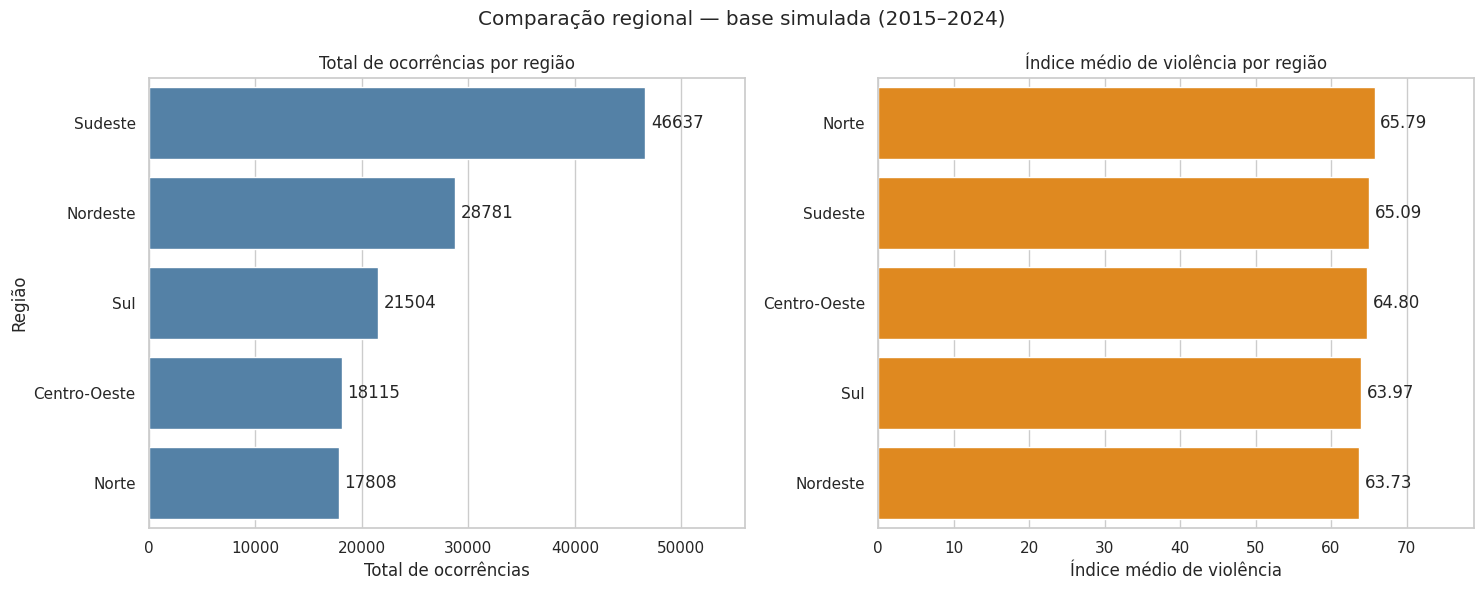

Região com mais ocorrências: Sudeste
Região com maior índice médio de violência: Norte


In [10]:
regioes = (
    df.groupby("regiao", as_index=False)
    .agg(
        cidades=("cidade", "nunique"),
        registros=("ocorrencias", "size"),
        total_ocorrencias=("ocorrencias", "sum"),
        media_por_registro=("ocorrencias", "mean"),
        indice_medio_violencia=("indice_violencia", "mean")
    )
    .sort_values("total_ocorrencias", ascending=False)
)

display(regioes.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=regioes,
    x="total_ocorrencias",
    y="regiao",
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Total de ocorrências por região")
axes[0].set_xlabel("Total de ocorrências")
axes[0].set_ylabel("Região")
axes[0].bar_label(axes[0].containers[0], fmt="%.0f", padding=4)
axes[0].set_xlim(0, regioes["total_ocorrencias"].max() * 1.2)

regioes_indice = regioes.sort_values(
    "indice_medio_violencia", ascending=False
)

sns.barplot(
    data=regioes_indice,
    x="indice_medio_violencia",
    y="regiao",
    color="darkorange",
    ax=axes[1]
)

axes[1].set_title("Índice médio de violência por região")
axes[1].set_xlabel("Índice médio de violência")
axes[1].set_ylabel("")
axes[1].bar_label(axes[1].containers[0], fmt="%.2f", padding=4)
axes[1].set_xlim(
    0, regioes_indice["indice_medio_violencia"].max() * 1.2
)

fig.suptitle("Comparação regional — base simulada (2015–2024)")
plt.tight_layout()
plt.show()

print(
    "Região com mais ocorrências:",
    regioes.iloc[0]["regiao"]
)

print(
    "Região com maior índice médio de violência:",
    regioes_indice.iloc[0]["regiao"]
)

O total de ocorrências depende também da quantidade de cidades e
registros de cada região na base. A média por registro ajuda a comparar
os volumes considerando essa diferença de cobertura, mas não é uma
taxa por habitante.

O índice médio de violência é uma medida distinta do total de
ocorrências. Sua fórmula não foi informada, portanto a comparação
é descritiva e limitada à base simulada.

### 7.5. Ocorrências por tipo de crime e período do dia
O mapa de calor apresenta a soma das ocorrências por tipo de crime
e período do dia. Cores mais intensas representam maiores quantidades
na base simulada.

periodo_dia,Madrugada,Manhã,Tarde,Noite
tipo_crime,,,,
Estelionato,5456,6001,5378,5052
Furto,5782,4963,5495,4939
Homicídio,5611,5323,5626,4937
Roubo,6395,5227,5804,6014
Tráfico,5635,5660,6416,5626
Violência doméstica,4881,5756,5238,5630


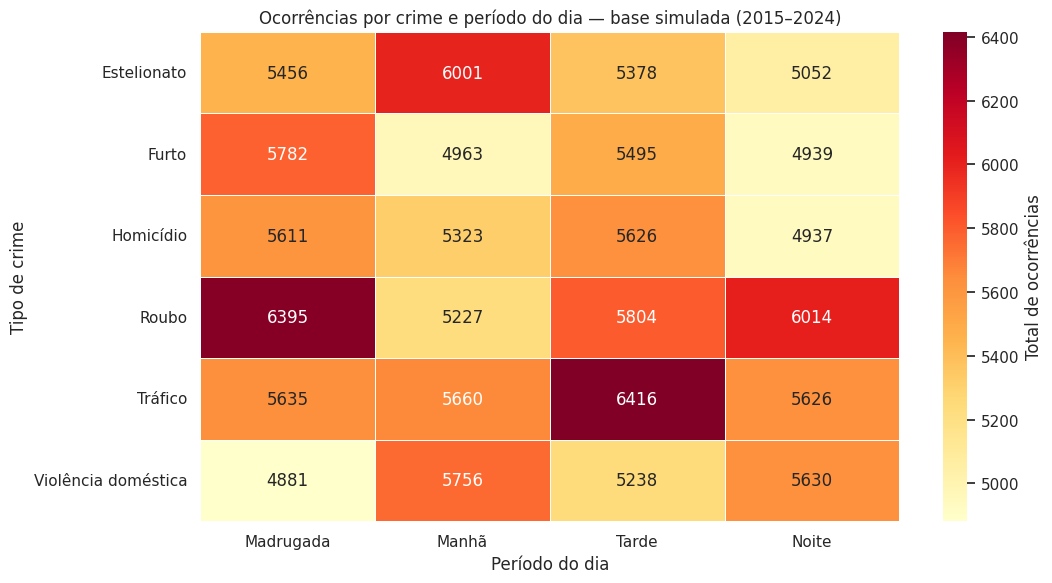

,registros,total_ocorrencias,media_por_registro
periodo_dia,,,
Madrugada,1131,33760,29.85
Manhã,1104,32930,29.83
Tarde,1134,33957,29.94
Noite,1071,32198,30.06


Período com mais ocorrências: Tarde
Combinação com mais ocorrências: Tráfico — Tarde


In [11]:
ordem_periodos = ["Madrugada", "Manhã", "Tarde", "Noite"]

tabela_periodos = df.pivot_table(
    index="tipo_crime",
    columns="periodo_dia",
    values="ocorrencias",
    aggfunc="sum",
    fill_value=0
).reindex(columns=ordem_periodos, fill_value=0)

display(tabela_periodos)

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(
    tabela_periodos,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Total de ocorrências"},
    ax=ax
)

ax.set_title(
    "Ocorrências por crime e período do dia — base simulada (2015–2024)"
)
ax.set_xlabel("Período do dia")
ax.set_ylabel("Tipo de crime")
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

resumo_periodos = (
    df.groupby("periodo_dia")
    .agg(
        registros=("ocorrencias", "size"),
        total_ocorrencias=("ocorrencias", "sum"),
        media_por_registro=("ocorrencias", "mean")
    )
    .reindex(ordem_periodos)
)

display(resumo_periodos.round(2))

periodo_maior = resumo_periodos["total_ocorrencias"].idxmax()
combinacao_maior = tabela_periodos.stack().idxmax()

print("Período com mais ocorrências:", periodo_maior)
print(
    "Combinação com mais ocorrências:",
    combinacao_maior[0], "—", combinacao_maior[1]
)

O heatmap permite identificar as combinações de crime e período
que concentram mais ocorrências na base.

Os totais também dependem da quantidade de registros em cada grupo.
A tabela complementar apresenta essa quantidade e a média por registro.
Como não há horários exatos nem duração dos períodos, os resultados
não representam taxas de ocorrências por hora.

### 7.6. Relação entre renda média e violência
O gráfico de dispersão e a correlação de Pearson serão utilizados
para examinar a associação linear entre renda média e índice de
violência nos registros da base simulada.

A correlação varia de -1 a 1 e não demonstra uma relação de causa e efeito.

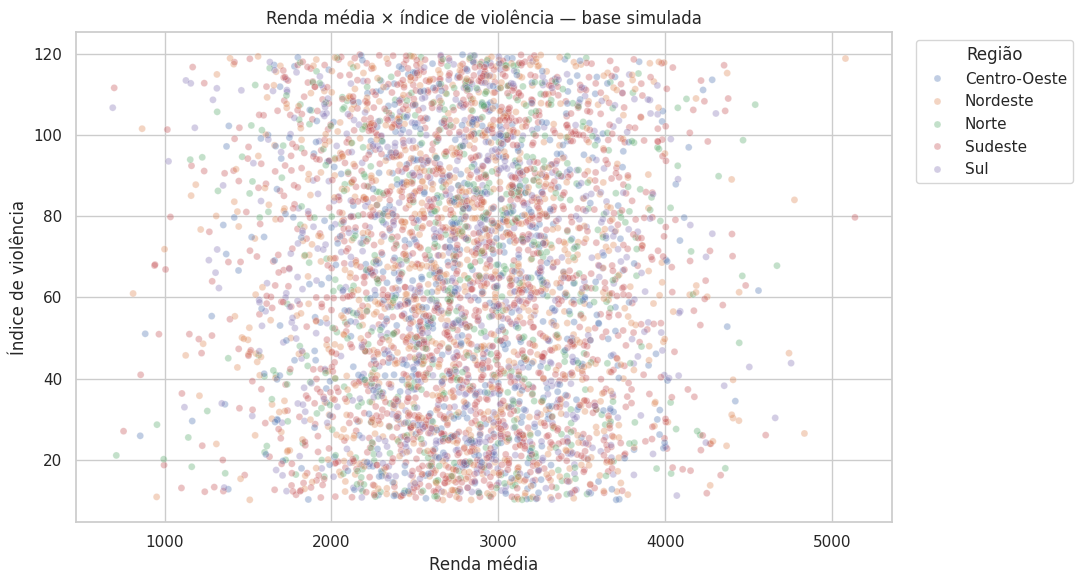

Correlação entre renda e índice de violência: -0.0135
Correlação entre renda e quantidade de ocorrências: 0.0164


,renda_media,indice_violencia,ocorrencias
renda_media,1.0000,-0.0135,0.0164
indice_violencia,-0.0135,1.0000,0.0282
ocorrencias,0.0164,0.0282,1.0000


In [12]:
dados_correlacao = df[
    ["renda_media", "indice_violencia", "ocorrencias"]
].dropna()

correlacao_violencia = dados_correlacao["renda_media"].corr(
    dados_correlacao["indice_violencia"]
)

correlacao_ocorrencias = dados_correlacao["renda_media"].corr(
    dados_correlacao["ocorrencias"]
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="renda_media",
    y="indice_violencia",
    hue="regiao",
    alpha=0.35,
    s=25,
    ax=ax
)

ax.set_title("Renda média × índice de violência — base simulada")
ax.set_xlabel("Renda média")
ax.set_ylabel("Índice de violência")
ax.legend(title="Região", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(
    f"Correlação entre renda e índice de violência: "
    f"{correlacao_violencia:.4f}"
)

print(
    f"Correlação entre renda e quantidade de ocorrências: "
    f"{correlacao_ocorrencias:.4f}"
)

display(dados_correlacao.corr().round(4))

In [13]:
if pd.isna(correlacao_violencia):
    print("Não foi possível calcular a correlação.")
elif abs(correlacao_violencia) < 0.1:
    print(
        "A correlação entre renda média e índice de violência "
        "está próxima de zero, indicando pouca associação linear "
        "nos registros analisados."
    )
else:
    sentido = "positiva" if correlacao_violencia > 0 else "negativa"

    print(
        f"A associação linear é {sentido}, com coeficiente "
        f"de {correlacao_violencia:.4f}. "
        "A intensidade deve ser avaliada junto com o gráfico."
    )

print(
    "Os resultados são descritivos, utilizam dados simulados "
    "e não permitem concluir que a renda causa mudanças na violência."
)

A correlação entre renda média e índice de violência está próxima de zero, indicando pouca associação linear nos registros analisados.
Os resultados são descritivos, utilizam dados simulados e não permitem concluir que a renda causa mudanças na violência.


### 7.7. Análise por nível de risco
Serão comparadas as ocorrências e o índice médio de violência
entre os níveis de risco fornecidos pela base.

As classificações originais serão preservadas, pois seus critérios
não foram informados.

,registros,total_ocorrencias,media_ocorrencias,indice_medio_violencia
nivel_risco,,,,
Baixo,1106,33185,30.00,65.03
Médio,1071,31979,29.86,64.05
Alto,1126,33765,29.99,64.39
Crítico,1137,33916,29.83,65.19


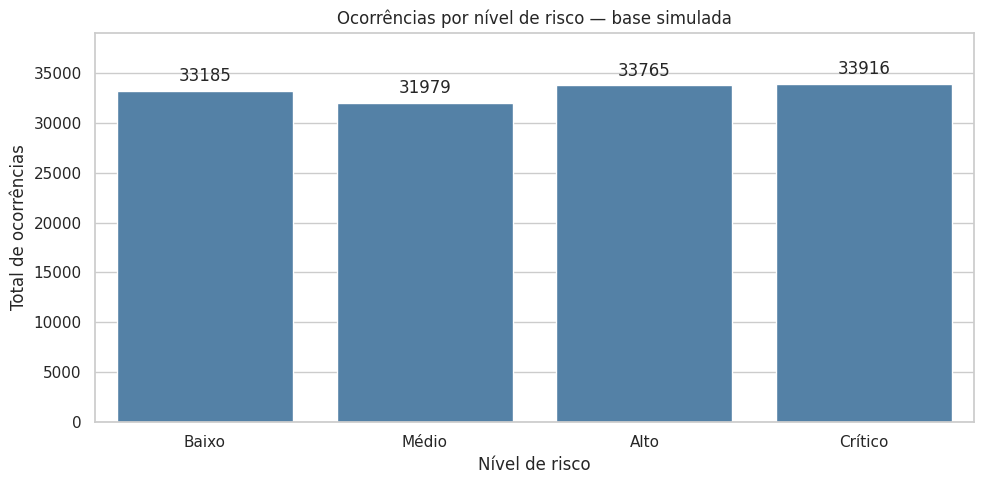

In [14]:
ordem_riscos = ["Baixo", "Médio", "Alto", "Crítico"]

resumo_riscos = (
    df.groupby("nivel_risco")
    .agg(
        registros=("ocorrencias", "size"),
        total_ocorrencias=("ocorrencias", "sum"),
        media_ocorrencias=("ocorrencias", "mean"),
        indice_medio_violencia=("indice_violencia", "mean")
    )
    .reindex(ordem_riscos)
)

display(resumo_riscos.round(2))

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=resumo_riscos.reset_index(),
    x="nivel_risco",
    y="total_ocorrencias",
    order=ordem_riscos,
    color="steelblue",
    ax=ax
)

ax.set_title("Ocorrências por nível de risco — base simulada")
ax.set_xlabel("Nível de risco")
ax.set_ylabel("Total de ocorrências")
ax.bar_label(ax.containers[0], fmt="%.0f", padding=4)
ax.set_ylim(0, resumo_riscos["total_ocorrencias"].max() * 1.15)

plt.tight_layout()
plt.show()

### 7.8. Tabela dinâmica por região e tipo de crime
A tabela apresenta o total de ocorrências de cada tipo de crime
por região, permitindo comparar a distribuição dos registros.

In [15]:
tabela_regiao_crime = pd.pivot_table(
    df,
    index="regiao",
    columns="tipo_crime",
    values="ocorrencias",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="Total"
)

display(tabela_regiao_crime)

tipo_crime,Estelionato,Furto,Homicídio,Roubo,Tráfico,Violência doméstica,Total
regiao,,,,,,,
Centro-Oeste,3236,2909,2733,3330,3251,2656,18115
Nordeste,4849,4359,4105,5480,4692,5296,28781
Norte,3217,2595,3315,2706,3065,2910,17808
Sudeste,7117,7702,7472,8371,8609,7366,46637
Sul,3468,3614,3872,3553,3720,3277,21504
Total,21887,21179,21497,23440,23337,21505,132845


Os totais por nível de risco dependem também da quantidade de registros
em cada categoria. A média de ocorrências e o índice médio complementam
essa comparação.

Não se presume que a classificação de risco seja determinada pelo
índice de violência, pois a base não informa essa regra.

A tabela dinâmica permite comparar crimes e regiões, considerando
que a cobertura de cidades varia entre as regiões.

## 8. Interpretação dos resultados
O resumo abaixo reúne os principais resultados calculados nas análises.
Todas as informações se referem exclusivamente à base simulada.

In [16]:
cidade_lider, uf_lider = ranking_cidades.index[0]
crime_lider = ranking_crimes.index[0]
regiao_lider = ranking_regioes_indice.index[0]
periodo_lider = resumo_periodos["total_ocorrencias"].idxmax()

total_inicial = ocorrencias_ano.iloc[0]["ocorrencias"]
total_final = ocorrencias_ano.iloc[-1]["ocorrencias"]
variacao_total = (total_final / total_inicial - 1) * 100

movimento = "aumento" if variacao_total >= 0 else "redução"

print(f"Total de ocorrências: {df['ocorrencias'].sum():.0f}")
print(f"Total de vítimas: {df['vitimas'].sum():.0f}")
print(f"Total de prisões: {df['prisoes'].sum():.0f}")

print(
    f"\n{cidade_lider} — {uf_lider} apresentou o maior total "
    f"por cidade, com {ranking_cidades.iloc[0]:.0f} ocorrências."
)

print(
    f"{crime_lider} foi o tipo de crime com mais ocorrências, "
    f"totalizando {ranking_crimes.iloc[0]:.0f}."
)

print(
    f"A região {regiao_lider} apresentou o maior índice médio "
    f"de violência: {ranking_regioes_indice.iloc[0]:.2f}."
)

print(f"O período com mais ocorrências foi: {periodo_lider}.")

print(
    f"\nEntre 2015 e 2024, houve {movimento} de "
    f"{abs(variacao_total):.2f}% no total anual de ocorrências."
)

print(
    "Essa comparação entre os extremos não demonstra "
    "uma tendência contínua durante todo o período."
)

print(
    f"\nCorrelação entre renda e índice de violência: "
    f"{correlacao_violencia:.4f}."
)

print(
    "A correlação descreve uma associação linear "
    "e não demonstra causa e efeito."
)

Total de ocorrências: 132845
Total de vítimas: 22220
Total de prisões: 13219

Florianópolis — SC apresentou o maior total por cidade, com 3707 ocorrências.
Roubo foi o tipo de crime com mais ocorrências, totalizando 23440.
A região Norte apresentou o maior índice médio de violência: 65.79.
O período com mais ocorrências foi: Tarde.

Entre 2015 e 2024, houve redução de 0.11% no total anual de ocorrências.
Essa comparação entre os extremos não demonstra uma tendência contínua durante todo o período.

Correlação entre renda e índice de violência: -0.0135.
A correlação descreve uma associação linear e não demonstra causa e efeito.


## 9. Conclusão

A análise comparou ocorrências por ano, cidade, região, tipo de crime
e período do dia, além de investigar a relação entre renda e violência.

Os resultados são limitados à base simulada e não representam a
segurança real das cidades. Os rankings utilizam valores absolutos,
sem ajuste pela população, e a correlação não indica causa e efeito.

O dashboard permitirá explorar os resultados com filtros interativos.

## 10. Persistência em SQLite
Os dados preparados serão armazenados em SQLite com SQLAlchemy,
permitindo consultas SQL.

In [17]:
%pip -q install sqlalchemy

In [18]:
from pathlib import Path
from sqlalchemy import create_engine, text

Path("/content/dados").mkdir(exist_ok=True)
Path("/content/database").mkdir(exist_ok=True)

df.to_csv(
    "/content/dados/criminalidade_tratada.csv",
    index=False,
    encoding="utf-8-sig"
)

engine = create_engine(
    "sqlite:////content/database/criminalidade.db"
)

with engine.begin() as conexao:
    df.to_sql(
        "criminalidade",
        con=conexao,
        if_exists="replace",
        index=False
    )

    consulta = pd.read_sql_query(
        text("""
            SELECT regiao,
                   SUM(ocorrencias) AS total_ocorrencias
            FROM criminalidade
            GROUP BY regiao
            ORDER BY total_ocorrencias DESC
        """),
        conexao
    )

    total_banco = conexao.execute(
        text("SELECT COUNT(*) FROM criminalidade")
    ).scalar_one()

display(consulta)

print("Registros no banco:", total_banco)
print("CSV tratado e banco SQLite salvos!")

engine.dispose()

,regiao,total_ocorrencias
0,Sudeste,46637
1,Nordeste,28781
2,Sul,21504
3,Centro-Oeste,18115
4,Norte,17808


Registros no banco: 4440
CSV tratado e banco SQLite salvos!


In [19]:
from google.colab import files

files.download("/content/dados/criminalidade_tratada.csv")
files.download("/content/database/criminalidade.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>